# Imports

In [2]:
import keras
import numpy as np
import gymnasium as gym
import tensorflow as tf
import matplotlib.pyplot as plt
from copy import deepcopy

import os, time
from IPython.display import display, HTML, clear_output

In [3]:
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
              tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

# Environment

Create the [environment](https://gymnasium.farama.org/environments/box2d/bipedal_walker/).

In [4]:
NUM_ENVS = 1

env = gym.make("BipedalWalker-v3")

obs_dim = env.observation_space.shape[0]  # 24
act_dim = env.action_space.shape[0]       # 4
act_high = env.action_space.high[0]       # 1.0
act_low = env.action_space.low[0]         # -1.0

print(f"Observation space: {env.observation_space}")
print(f"Action space: {env.action_space}")
print(f"obs_dim={obs_dim}, act_dim={act_dim}, act_range=[{act_low}, {act_high}]")

Observation space: Box([-3.1415927 -5.        -5.        -5.        -3.1415927 -5.
 -3.1415927 -5.        -0.        -3.1415927 -5.        -3.1415927
 -5.        -0.        -1.        -1.        -1.        -1.
 -1.        -1.        -1.        -1.        -1.        -1.       ], [3.1415927 5.        5.        5.        3.1415927 5.        3.1415927
 5.        5.        3.1415927 5.        3.1415927 5.        5.
 1.        1.        1.        1.        1.        1.        1.
 1.        1.        1.       ], (24,), float32)
Action space: Box(-1.0, 1.0, (4,), float32)
obs_dim=24, act_dim=4, act_range=[-1.0, 1.0]


C:\Users\maxim\anaconda3\envs\ocrlab\lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


# Replay Buffer

Create a replay buffer to hold game history

online actor→actions→environment→replay buffer→target actor + target critic→target y→online critic→policy loss→online actor

online actor→target actor
online critic→target critic

In [5]:
class ReplayBuffer:

    def __init__(self, max_size: int, observation_space: gym.spaces.Space, action_space: gym.spaces.Space, seed: int | None = None):
        
        self.max_size = max_size
        self.rng = np.random.default_rng(seed)
        self.ptr = 0  
        self.size = 0

        obs_shape = observation_space.shape
        act_shape = action_space.shape

        self.current_observations = np.zeros((max_size, *obs_shape), dtype=np.float32)
        self.actions = np.zeros((max_size, *act_shape), dtype=np.float32)
        self.rewards = np.zeros((max_size,), dtype=np.float32)
        self.next_observations = np.zeros((max_size, *obs_shape), dtype=np.float32)
        self.dones = np.zeros((max_size,), dtype=np.float32)

    def add(self, current_observations: np.ndarray, actions: np.ndarray, rewards: np.ndarray, next_observations: np.ndarray, dones: np.ndarray) -> None:

        current_observations = np.atleast_2d(current_observations)
        actions = np.atleast_2d(actions)
        rewards = np.atleast_1d(rewards)
        next_observations = np.atleast_2d(next_observations)
        dones = np.atleast_1d(dones)

        batch_size = current_observations.shape[0]
        for i in range(batch_size):
            self.current_observations[self.ptr] = current_observations[i]
            self.actions[self.ptr] = actions[i]
            self.rewards[self.ptr] = rewards[i]
            self.next_observations[self.ptr] = next_observations[i]
            self.dones[self.ptr] = dones[i]
            self.ptr = (self.ptr + 1) % self.max_size
            self.size = min(self.size + 1, self.max_size)

    def sample(self, n_samples: int, replace: bool = True) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        indices = self.rng.choice(self.size, size=n_samples, replace=replace)
        return self[indices]

    def clear(self) -> None:
        self.ptr = 0
        self.size = 0

    def __getitem__(self, index: int | np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        return (
            self.current_observations[index],
            self.actions[index],
            self.rewards[index],
            self.next_observations[index],
            self.dones[index],
        )

    def __len__(self) -> int:
        return self.size

# Model

In [6]:
@keras.saving.register_keras_serializable()
class ScaleLayer(keras.layers.Layer):
    def __init__(self, scale: float, **kwargs):
        super().__init__(**kwargs)
        self.scale = scale

    def call(self, inputs):
        return inputs * self.scale

    def get_config(self):
        config = super().get_config()
        config.update({"scale": self.scale})
        return config

# online actor
def build_policy_model(obs_dim: int, act_dim: int, act_high: float) -> keras.Model:

    obs_input = keras.Input(shape=(obs_dim,), name="observation")
    x = keras.layers.Dense(400, activation="relu")(obs_input)
    x = keras.layers.Dense(300, activation="relu")(x)
    # tanh output scaled to action range
    raw = keras.layers.Dense(act_dim, activation="tanh")(x)
    actions = ScaleLayer(act_high)(raw)
    model = keras.Model(inputs=obs_input, outputs=actions, name="policy")
    return model

# online critic
def build_q_model(obs_dim: int, act_dim: int) -> keras.Model:

    obs_input = keras.Input(shape=(obs_dim,), name="observation")
    act_input = keras.Input(shape=(act_dim,), name="action")
    concat = keras.layers.Concatenate()([obs_input, act_input])
    x = keras.layers.Dense(400, activation="relu")(concat)
    x = keras.layers.Dense(300, activation="relu")(x)
    q_value = keras.layers.Dense(1, activation=None)(x)
    model = keras.Model(inputs=[obs_input, act_input], outputs=q_value, name="q_function")
    return model


def clone_model(source: keras.Model) -> keras.Model:

    clone = keras.models.clone_model(source)
    clone.set_weights(source.get_weights())
    return clone


def soft_update(target: keras.Model, source: keras.Model, tau: float) -> None:

    for t_w, s_w in zip(target.weights, source.weights):
        t_w.assign(tau * s_w + (1.0 - tau) * t_w)

# Sampler (exploration noise)

In [7]:
class Sampler:

    def __init__(self, act_dim: int, mu: float = 0.0, theta: float = 0.15, sigma: float = 0.2, seed: int | None = None):
        self.act_dim = act_dim
        self.mu = mu
        self.theta = theta
        self.sigma = sigma
        self.rng = np.random.default_rng(seed)
        self.state = np.full(act_dim, mu, dtype=np.float32)
        self._sigma_current = sigma

    def __call__(self) -> np.ndarray:

        dx = self.theta * (self.mu - self.state) + self._sigma_current * self.rng.standard_normal(self.act_dim).astype(np.float32)
        self.state = self.state + dx
        return self.state.copy()

    def reset(self) -> None:
        self.state = np.full(self.act_dim, self.mu, dtype=np.float32)

    def set_sigma(self, sigma: float) -> None:

        self._sigma_current = sigma

# Play the game

Implement interacting with the environment and storing entries to the replay buffer

In [8]:
def play_game(
    model: keras.Model,
    buffer: ReplayBuffer,
    env: gym.Env,
    steps: int,
    sampler: Sampler,
    observations: np.ndarray | None = None,
    one_episode: bool = False
) -> np.ndarray:
 
    if observations is None:
        observations, _ = env.reset()
    
    episode_reward = 0.0
    
    for _ in range(steps):
        obs_tensor = np.expand_dims(observations, axis=0).astype(np.float32)
        action = model(obs_tensor, training=False).numpy()[0]
        
        # Add exploration noise
        noise = sampler()
        action = np.clip(action + noise, env.action_space.low, env.action_space.high)
        
        next_observations, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        buffer.add(observations, action, np.array([reward]), next_observations, np.array([float(done)]))
        episode_reward += reward
        
        if done:
            if one_episode:
                return next_observations
            observations, _ = env.reset()
            sampler.reset()
        else:
            observations = next_observations
    
    return observations

# Loss

Implement ddpg loss

In [9]:
def ddpg_loss(
    current_observation: keras.KerasTensor, 
    action: keras.KerasTensor, 
    reward: keras.KerasTensor, 
    next_observation: keras.KerasTensor, 
    done: keras.KerasTensor,
    q_model: keras.Model,
    policy_model: keras.Model,
    target_q_model: keras.Model,
    target_policy_model: keras.Model,
    gamma: float
) -> tuple[keras.KerasTensor, keras.KerasTensor]:

    
    # Critic (Q-function) loss 
    # Compute target: y = r + gamma * (1 - done) * Q_target(s', mu_target(s'))
    next_actions = target_policy_model(next_observation, training=False) # Какое действие он бы сделал в следующем состоянии?
    target_q_values = target_q_model([next_observation, next_actions], training=False) # Насколько хорошее будущее состояние s' и действие a'?
    target_q_values = tf.squeeze(target_q_values, axis=-1)  # [B]
    
    y = reward + gamma * (1.0 - done) * target_q_values  # [B]  # екущая ценность действия = текущая награда + будущая ожидаемая награда.
    y = tf.stop_gradient(y) # обучаем critic приближаться к y, но не меняем target-сети через этот loss.
    
    # Current Q estimate
    current_q = q_model([current_observation, action], training=True) # Как critic сейчас оценивает реально сделанное действие a в состоянии s
    current_q = tf.squeeze(current_q, axis=-1)  # [B]
    
    q_loss = tf.reduce_mean(tf.square(current_q - y)) # Если critic ошибся относительно Bellman target y, мы его штрафуем.
    
    # Actor (Policy) loss
    # Maximize Q(s, mu(s)) => minimize -Q(s, mu(s))
    predicted_actions = policy_model(current_observation, training=True) # Какое действие actor сейчас выбрал бы в состоянии
    q_for_policy = q_model([current_observation, predicted_actions], training=False) # Насколько хорошее действие сейчас предлагает actor
    
    policy_loss = -tf.reduce_mean(q_for_policy) # Чем выше Q, тем меньше loss. Значит actor будет учиться выбирать действия с большим Q
    
    return q_loss, policy_loss

# Training

Create models, replay buffers, optimizer, epsilon decay etc. Implement training loop, show training progress and perform model evaluation once in a while

In [10]:
BUFFER_SIZE   = 1_000_000
BATCH_SIZE    = 256
GAMMA         = 0.99
TAU           = 0.005
LR_ACTOR      = 1e-4
LR_CRITIC     = 1e-3
WARMUP_STEPS  = 10_000
TOTAL_STEPS   = 1_000_000
TRAIN_EVERY   = 1   
EVAL_EVERY    = 10_000
SIGMA_START   = 0.2
SIGMA_END     = 0.05
SIGMA_DECAY_STEPS = 500_000
SEED          = 999

# Build models
policy_model = build_policy_model(obs_dim, act_dim, act_high)
q_model = build_q_model(obs_dim, act_dim)

# Target networks (initialized as copies)
target_policy_model = clone_model(policy_model)
target_q_model = clone_model(q_model)

# Optimizers
actor_optimizer = keras.optimizers.Adam(learning_rate=LR_ACTOR)
critic_optimizer = keras.optimizers.Adam(learning_rate=LR_CRITIC)

# Replay buffer
buffer = ReplayBuffer(BUFFER_SIZE, env.observation_space, env.action_space, seed=SEED)

# Exploration noise
sampler = Sampler(act_dim, sigma=SIGMA_START, seed=SEED)

policy_model.summary()
q_model.summary()

Model: "policy"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ observation (InputLayer)             │ (None, 24)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 400)                 │          10,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 300)                 │         120,300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │           1,204 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ scale_layer (ScaleLayer)             │ (None, 4)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 131,504 (513.69 KB)

 Trainable params: 131,504 (513.69 KB)

 Non-trainable params: 0 (0.00 B)

Model: "q_function"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ observation (InputLayer)      │ (None, 24)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ action (InputLayer)           │ (None, 4)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 28)                │               0 │ observation[0][0],         │
│                               │                           │                 │ action[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 400)               │          11,600 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 300)               │         120,300 │ dense_3[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 1)                 │             301 │ dense_4[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 132,201 (516.41 KB)

 Trainable params: 132,201 (516.41 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
@tf.function
def train_step(obs, act, rew, next_obs, done):
    # Update critic 
    with tf.GradientTape() as tape:
        q_loss, _ = ddpg_loss(
            obs, act, rew, next_obs, done,
            q_model, policy_model,
            target_q_model, target_policy_model,
            GAMMA
        )
    q_grads = tape.gradient(q_loss, q_model.trainable_variables)
    critic_optimizer.apply_gradients(zip(q_grads, q_model.trainable_variables))

    # Update actor
    with tf.GradientTape() as tape:
        _, p_loss = ddpg_loss(
            obs, act, rew, next_obs, done,
            q_model, policy_model,
            target_q_model, target_policy_model,
            GAMMA
        )
    p_grads = tape.gradient(p_loss, policy_model.trainable_variables)
    actor_optimizer.apply_gradients(zip(p_grads, policy_model.trainable_variables))

    return q_loss, p_loss

In [12]:
def evaluate(policy: keras.Model, n_episodes: int = 5) -> float:
    eval_env = gym.make("BipedalWalker-v3")
    total_rewards = []
    for _ in range(n_episodes):
        obs, _ = eval_env.reset()
        ep_reward = 0.0
        done = False
        while not done:
            action = policy(np.expand_dims(obs, 0).astype(np.float32), training=False).numpy()[0]
            obs, reward, terminated, truncated, _ = eval_env.step(action)
            ep_reward += reward
            done = terminated or truncated
        total_rewards.append(ep_reward)
    eval_env.close()
    return np.mean(total_rewards)

In [12]:
SAVE_DIR = "best_model"
os.makedirs(SAVE_DIR, exist_ok=True)

obs, _ = env.reset(seed=SEED)

episode_rewards = []
eval_rewards = []
eval_steps = []
current_ep_reward = 0.0
q_losses = []
p_losses = []
best_eval_reward = -np.inf

LOG_EVERY = 2000
t_start = time.time()
last_log_time = t_start

def print_progress(step, extra=""):
    """Print a single-line progress update."""
    elapsed = time.time() - t_start
    pct = 100.0 * step / TOTAL_STEPS
    sps = step / elapsed if elapsed > 0 else 0
    eta = (TOTAL_STEPS - step) / sps if sps > 0 else 0
    eta_m, eta_s = divmod(int(eta), 60)
    eta_h, eta_m = divmod(eta_m, 60)
    last100 = np.mean(episode_rewards[-100:]) if episode_rewards else float('nan')
    msg = (f"Step {step:>7d}/{TOTAL_STEPS} ({pct:5.1f}%) | "
           f"{sps:.0f} steps/s | ETA {eta_h:d}h{eta_m:02d}m | "
           f"episodes: {len(episode_rewards)} | "
           f"last100: {last100:.1f} | buf: {len(buffer)}")
    if extra:
        msg += f" | {extra}"
    print(msg, flush=True)

for step in range(TOTAL_STEPS):

    if step < SIGMA_DECAY_STEPS:
        sigma = SIGMA_START + (SIGMA_END - SIGMA_START) * (step / SIGMA_DECAY_STEPS)
    else:
        sigma = SIGMA_END
    sampler.set_sigma(sigma)


    if step < WARMUP_STEPS:
        action = env.action_space.sample()
    else:
        obs_t = np.expand_dims(obs, 0).astype(np.float32)
        action = policy_model(obs_t, training=False).numpy()[0]
        noise = sampler()
        action = np.clip(action + noise, act_low, act_high)

    next_obs, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    buffer.add(obs, action, np.array([reward]), next_obs, np.array([float(done)]))
    current_ep_reward += reward

    if done:
        episode_rewards.append(current_ep_reward)
        current_ep_reward = 0.0
        obs, _ = env.reset()
        sampler.reset()
    else:
        obs = next_obs

    if step >= WARMUP_STEPS and step % TRAIN_EVERY == 0:
        batch_obs, batch_act, batch_rew, batch_next_obs, batch_done = buffer.sample(BATCH_SIZE)
        batch_obs = tf.constant(batch_obs, dtype=tf.float32)
        batch_act = tf.constant(batch_act, dtype=tf.float32)
        batch_rew = tf.constant(batch_rew, dtype=tf.float32)
        batch_next_obs = tf.constant(batch_next_obs, dtype=tf.float32)
        batch_done = tf.constant(batch_done, dtype=tf.float32)

        ql, pl = train_step(batch_obs, batch_act, batch_rew, batch_next_obs, batch_done)
        q_losses.append(ql.numpy())
        p_losses.append(pl.numpy())

        # Soft update target networks
        soft_update(target_q_model, q_model, TAU)
        soft_update(target_policy_model, policy_model, TAU)

    if step > 0 and step % LOG_EVERY == 0:
        print_progress(step)

    if step > 0 and step % EVAL_EVERY == 0:
        mean_r = evaluate(policy_model, n_episodes=5)
        eval_rewards.append(mean_r)
        eval_steps.append(step)

        if mean_r > best_eval_reward:
            best_eval_reward = mean_r
            policy_model.save(os.path.join(SAVE_DIR, "policy_best.keras"))
            q_model.save(os.path.join(SAVE_DIR, "q_best.keras"))

        print_progress(step, extra=f"EVAL={mean_r:.1f}  BEST={best_eval_reward:.1f}  σ={sigma:.3f}")

elapsed_total = time.time() - t_start
print(f"\nTraining finished in {elapsed_total/3600:.1f}h")

env.close()

best_policy_path = os.path.join(SAVE_DIR, "policy_best.keras")
if os.path.exists(best_policy_path):
    policy_model = keras.models.load_model(best_policy_path, safe_mode=False)
    print(f"Loaded best policy model (eval reward = {best_eval_reward:.2f})")

Step    2000/1000000 (  0.2%) | 2429 steps/s | ETA 0h06m | episodes: 5 | last100: -105.1 | buf: 2001
Step    4000/1000000 (  0.4%) | 2494 steps/s | ETA 0h06m | episodes: 8 | last100: -104.1 | buf: 4001
Step    6000/1000000 (  0.6%) | 2498 steps/s | ETA 0h06m | episodes: 15 | last100: -104.4 | buf: 6001
Step    8000/1000000 (  0.8%) | 2473 steps/s | ETA 0h06m | episodes: 23 | last100: -104.6 | buf: 8001
Step   10000/1000000 (  1.0%) | 1617 steps/s | ETA 0h10m | episodes: 24 | last100: -103.7 | buf: 10001
Step   10000/1000000 (  1.0%) | 1120 steps/s | ETA 0h14m | episodes: 24 | last100: -103.7 | buf: 10001 | EVAL=-117.4  BEST=-117.4  σ=0.197
Step   12000/1000000 (  1.2%) | 245 steps/s | ETA 1h07m | episodes: 27 | last100: -105.9 | buf: 12001
Step   14000/1000000 (  1.4%) | 158 steps/s | ETA 1h44m | episodes: 36 | last100: -111.5 | buf: 14001
Step   16000/1000000 (  1.6%) | 126 steps/s | ETA 2h10m | episodes: 55 | last100: -111.7 | buf: 16001
Step   18000/1000000 (  1.8%) | 108 steps/s | 

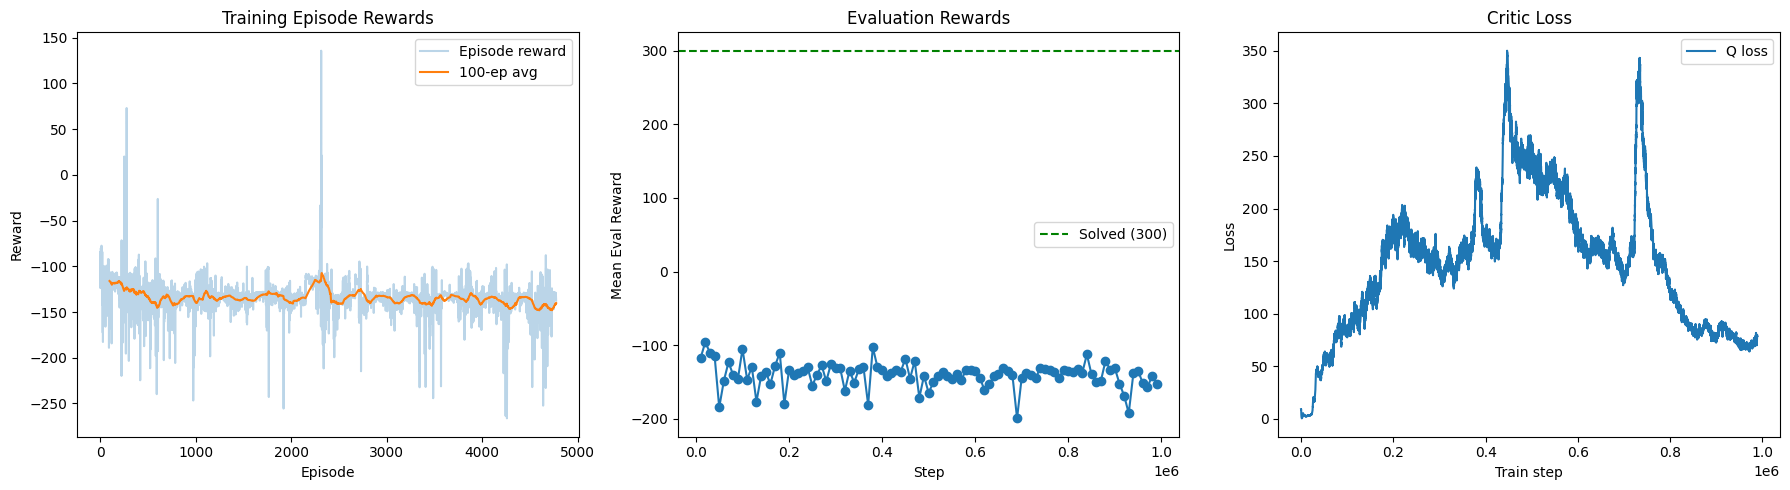

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(episode_rewards, alpha=0.3, label="Episode reward")
if len(episode_rewards) >= 100:
    smoothed = np.convolve(episode_rewards, np.ones(100)/100, mode='valid')
    axes[0].plot(range(99, len(episode_rewards)), smoothed, label="100-ep avg")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward")
axes[0].set_title("Training Episode Rewards")
axes[0].legend()

axes[1].plot(eval_steps, eval_rewards, 'o-')
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Mean Eval Reward")
axes[1].set_title("Evaluation Rewards")
axes[1].axhline(y=300, color='g', linestyle='--', label="Solved (300)")
axes[1].legend()

if q_losses:
    window = min(1000, len(q_losses))
    smooth_q = np.convolve(q_losses, np.ones(window)/window, mode='valid')
    axes[2].plot(smooth_q, label="Q loss")
axes[2].set_xlabel("Train step")
axes[2].set_ylabel("Loss")
axes[2].set_title("Critic Loss")
axes[2].legend()

plt.tight_layout()
plt.show()

# Testing

In [15]:
pip install "gymnasium[other]"

  Using cached moviepy-2.2.1-py3-none-any.whl.metadata (6.9 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached imageio_ffmpeg-0.6.0-py3-none-win_amd64.whl.metadata (1.5 kB)
  Using cached proglog-0.1.12-py3-none-any.whl.metadata (794 bytes)
  Using cached pillow-11.3.0-cp310-cp310-win_amd64.whl.metadata (9.2 kB)
  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
Using cached moviepy-2.2.1-py3-none-any.whl (129 kB)
Using cached pillow-11.3.0-cp310-cp310-win_amd64.whl (7.0 MB)
Using cached proglog-0.1.12-py3-none-any.whl (6.3 kB)
Using cached imageio_ffmpeg-0.6.0-py3-none-win_amd64.whl (31.2 MB)
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.8/40.2 MB 3.4 MB/s eta 0:00:12
    --------------------------------------- 0.8/40.2 MB 3.4

  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 5] Отказано в доступе: 'C:\\Users\\maxim\\anaconda3\\envs\\ocrlab\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [13]:
import os

SAVE_DIR = "best_model"

obs_dim = env.observation_space.shape[0]
act_dim = env.action_space.shape[0]
act_high = env.action_space.high[0]

policy_model = build_policy_model(obs_dim, act_dim, act_high)

best_path = os.path.join(SAVE_DIR, "policy_best.keras")
if os.path.exists(best_path):
    policy_model = keras.models.load_model(best_path, safe_mode=False)
    print(f"Loaded policy model from {best_path}")
else:
    print(f"WARNING: {best_path} not found! Using untrained model.")

test_obs, _ = env.reset()
total_r = 0.0
done = False
while not done:
    a = policy_model(np.expand_dims(test_obs, 0).astype(np.float32), training=False).numpy()[0]
    test_obs, r, term, trunc, _ = env.step(a)
    total_r += r
    done = term or trunc
print(f"Sanity check episode reward: {total_r:.2f}")

Loaded policy model from best_model\policy_best.keras
Sanity check episode reward: 258.54


In [14]:
from gymnasium.wrappers import RecordVideo
import os

# Record video of the trained agent
video_dir = "./videos2"
os.makedirs(video_dir, exist_ok=True)

test_env = gym.make("BipedalWalker-v3", render_mode="rgb_array")
test_env = RecordVideo(test_env, video_folder=video_dir, name_prefix="ddpg_bipedal",
                        episode_trigger=lambda x: True)

n_test_episodes = 5
test_rewards = []

for ep in range(n_test_episodes):
    obs, _ = test_env.reset()
    ep_reward = 0.0
    done = False
    while not done:
        action = policy_model(np.expand_dims(obs, 0).astype(np.float32), training=False).numpy()[0]
        obs, reward, terminated, truncated, _ = test_env.step(action)
        ep_reward += reward
        done = terminated or truncated
    test_rewards.append(ep_reward)
    print(f"Episode {ep+1}: reward = {ep_reward:.2f}")

test_env.close()
print(f"\nMean test reward: {np.mean(test_rewards):.2f} +/- {np.std(test_rewards):.2f}")
print(f"Videos saved to {video_dir}/")

C:\Users\maxim\anaconda3\envs\ocrlab\lib\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at C:\Users\maxim\RL\2\videos2 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Episode 1: reward = 258.65
Episode 2: reward = 255.64
Episode 3: reward = 254.71
Episode 4: reward = 124.72
Episode 5: reward = 260.62

Mean test reward: 230.87 +/- 53.12
Videos saved to ./videos2/


In [15]:
# Display the video inline (Jupyter)
from IPython.display import Video
import glob

video_files = sorted(glob.glob(os.path.join(video_dir, "*.mp4")))
if video_files:
    print(f"Showing: {video_files[0]}")
    Video(video_files[0], embed=True, width=600)

Showing: ./videos2\ddpg_bipedal-episode-0.mp4
